# Section 24: stronger validation (plan items 1, 4, 2)

Run the cells in order. Everything writes to `HIT_outputs_verified/validation/<timestamp>/` and only **reads** earlier outputs.

| Part | What | Time (Colab CPU) |
|---|---|---|
| A | Item 1: environment record and input hashes | ~2 min |
| B | Item 4: exploratory model sensitivity, including a check that the deployed model is reproduced | ~2 min |
| C | Item 2 pilot: label-pipeline recreation on the first 5 of the 60 E5 objects | ~15 min |
| D | Item 2 full: all 60 objects, depth offset 0 / 0.75 / 1.5 voxels | ~2–3 h (resume-safe) |

Item 2 is a **controlled re-implementation** of the 3DMSL mesh-fusion label step, written in NumPy from the code in `bioailab/3DMSL/occupancy_networks/external/mesh-fusion`. The original needs compiled OpenGL/CUDA libraries. Only the depth offset changes between conditions. Run C first and check its fidelity numbers before starting D.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, glob, json, hashlib, sys, platform, subprocess
from datetime import datetime, timezone
OUT_ROOT   = '/content/drive/MyDrive/HIT_outputs_verified'
FROZEN_DIR = os.path.join(OUT_ROOT, 'frozen_validation_1_1_2729', '20260924T193719_753199Z')
IDS_CSV    = os.path.join(OUT_ROOT, 'remaining_analyses', '20260924T201209Z', 'mechanism_offset_instances.csv')
DEV_ZIP    = '/content/drive/MyDrive/10_24553_27272.zip'
DATA_DIR   = '/content/data'
OUT = os.path.join(OUT_ROOT, 'validation', datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ'))
# To resume Part D after a disconnect, set OUT to the earlier folder instead, e.g.:
# OUT = os.path.join(OUT_ROOT, 'validation', '2026....Z')
os.makedirs(OUT, exist_ok=True)
for p in (FROZEN_DIR, IDS_CSV):
    assert os.path.exists(p), f'missing: {p}'
print('output:', OUT)

output: /content/drive/MyDrive/HIT_outputs_verified/validation/20260926T161230Z


In [3]:
!pip -q install trimesh scikit-image scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 12.7 MB/s eta 0:00:00


## A. Item 1: environment record and input hashes

In [4]:
def sha256(path, chunk=1 << 22):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for b in iter(lambda: f.read(chunk), b''): h.update(b)
    return h.hexdigest()
inputs = [os.path.join(FROZEN_DIR, 'frozen_inputs', 'validation_v3_model.json'),
          os.path.join(FROZEN_DIR, 'frozen_inputs', 'validation_v3_splits.csv'),
          os.path.join(FROZEN_DIR, 'frozen_predictions.csv'), os.path.join(FROZEN_DIR, 'audit.csv'), IDS_CSV]
rec = {'utc': datetime.now(timezone.utc).isoformat(), 'python': sys.version, 'platform': platform.platform(),
       'cpu_count': os.cpu_count(), 'inputs_sha256': {p: sha256(p) for p in inputs if os.path.exists(p)}}
HASH_ZIP = False   # set True to hash the 8 GB shard archive (~1-2 min)
if HASH_ZIP: rec['inputs_sha256'][DEV_ZIP] = sha256(DEV_ZIP)
open(os.path.join(OUT, 'env_lock.txt'), 'w').write(subprocess.run([sys.executable, '-m', 'pip', 'freeze'], capture_output=True, text=True).stdout)
json.dump(rec, open(os.path.join(OUT, 'environment_record.json'), 'w'), indent=1)
print(json.dumps(rec, indent=1))

{
 "utc": "2026-09-26T16:12:34.785826+00:00",
 "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
 "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
 "cpu_count": 2,
 "inputs_sha256": {
  "/content/drive/MyDrive/HIT_outputs_verified/frozen_validation_1_1_2729/20260924T193719_753199Z/frozen_inputs/validation_v3_model.json": "93b6daed1431d5cd11d83d8f90e1f4c9cec2e466866fee58f6d1e63f6be8be7f",
  "/content/drive/MyDrive/HIT_outputs_verified/frozen_validation_1_1_2729/20260924T193719_753199Z/frozen_inputs/validation_v3_splits.csv": "4c8432b9447caa6b89a5307cc3ba9cf6855dd44e6061138c6bfe3c90b7de34bc",
  "/content/drive/MyDrive/HIT_outputs_verified/frozen_validation_1_1_2729/20260924T193719_753199Z/frozen_predictions.csv": "df6edb0367dae8b0a4b573bdf7fe85bfefe9d9c16104a52a7b6476fe3294eb5b",
  "/content/drive/MyDrive/HIT_outputs_verified/frozen_validation_1_1_2729/20260924T193719_753199Z/audit.csv": "0f464a2941689f197b53a6ddfac0278becc24cfaf55755661198cf399e5adb83",
  "/content/driv

In [5]:
%%writefile /content/e5_boundary_refit.py
#!/usr/bin/env python3
"""Paper fix 3: rerun the E5 label-boundary fits with a convergence check.

For each object:
  * near-boundary occupancy query points are selected as in the original run
    (approximate distance from the 32 nearest triangle centroids, |d| < band,
    at most 3,000 points, fixed seed);
  * signed distances are computed twice: with the original 32-centroid
    approximation and EXACTLY (brute-force point-to-triangle distance over all
    faces, sign from the generalized winding number). This also answers the
    second E5 limitation, that the approximation was never validated;
  * P(inside | d) = 1 / (1 + exp((d - t50)/w)) is fitted by maximum likelihood
    (Bernoulli), from several starting points, and each fit is checked:
      - optimizer reports success
      - projected gradient small
      - t50 and w not on a parameter bound
      - all starts that reach the best likelihood agree on t50
      - both labels present (>= 20 points each) and the classes overlap
    Fits that fail any check are reported, not silently used.

Positive distance = outside the raw mesh, in normalized coordinates.
The volume-implied offset is t_vol = (V_o - V_m) / (A_m * s).
"""
import argparse, glob, json, os, re, sys, time
from datetime import datetime, timezone
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr

ORIGINAL = {"n": 60, "t50_median": 0.00304, "t50_iqr": [0.00285, 0.00317], "t50_cv": 0.09,
            "w_median": 0.00027, "t_vol_median": 0.00311, "ratio": 0.98, "per_object_r": 0.567}
PIPELINE = {"full_ray_offset": 1.5 / 256 / 0.9, "half_ray_offset": 0.5 * 1.5 / 256 / 0.9}


# ----------------------------------------------------------------- loading
def load_instance(d):
    import trimesh
    mesh = trimesh.load(os.path.join(d, "raw_mesh.off"), process=False, force="mesh")
    z = np.load(os.path.join(d, "occupancies.npz"))
    pts = z["points"].astype(np.float64)
    occ = z["occupancies"]
    if occ.dtype == np.uint8 and occ.size * 8 >= len(pts) and occ.size != len(pts):
        occ = np.unpackbits(occ)[: len(pts)]
    occ = occ.astype(bool).reshape(-1)
    loc = np.asarray(z["loc"], dtype=np.float64).reshape(3)
    scale = float(np.asarray(z["scale"]).reshape(()))
    return mesh, pts, occ, loc, scale


# ----------------------------------------------------------------- geometry
def closest_point_on_triangles(p, a, b, c):
    """Exact closest points (Ericson, Real-Time Collision Detection 5.1.5), vectorized.
    p: (m,1,3); a,b,c: (1,f,3) -> squared distances (m,f)."""
    ab, ac, ap = b - a, c - a, p - a
    d1 = np.einsum("...k,...k", ab, ap); d2 = np.einsum("...k,...k", ac, ap)
    bp = p - b
    d3 = np.einsum("...k,...k", ab, bp); d4 = np.einsum("...k,...k", ac, bp)
    cp = p - c
    d5 = np.einsum("...k,...k", ab, cp); d6 = np.einsum("...k,...k", ac, cp)
    va = d3 * d6 - d5 * d4; vb = d5 * d2 - d1 * d6; vc = d1 * d4 - d3 * d2
    denom = va + vb + vc
    with np.errstate(divide="ignore", invalid="ignore"):
        v = vb / denom; w = vc / denom
    q = a + ab * v[..., None] + ac * w[..., None]              # interior
    # edges
    with np.errstate(divide="ignore", invalid="ignore"):
        t_ab = d1 / (d1 - d3); t_ac = d2 / (d2 - d6); t_bc = (d4 - d3) / ((d4 - d3) + (d5 - d6))
    m_ab = (vc <= 0) & (d1 >= 0) & (d3 <= 0)
    m_ac = (vb <= 0) & (d2 >= 0) & (d6 <= 0)
    m_bc = (va <= 0) & ((d4 - d3) >= 0) & ((d5 - d6) >= 0)
    q = np.where(m_bc[..., None], b + (c - b) * t_bc[..., None], q)
    q = np.where(m_ac[..., None], a + ac * t_ac[..., None], q)
    q = np.where(m_ab[..., None], a + ab * t_ab[..., None], q)
    # vertices (checked last so they take precedence)
    q = np.where(((d6 >= 0) & (d5 <= d6))[..., None], np.broadcast_to(c, q.shape), q)
    q = np.where(((d3 >= 0) & (d4 <= d3))[..., None], np.broadcast_to(b, q.shape), q)
    q = np.where(((d1 <= 0) & (d2 <= 0))[..., None], np.broadcast_to(a, q.shape), q)
    diff = p - q
    return np.einsum("...k,...k", diff, diff)


def winding_number(P, V, F, chunk=None):
    """Generalized winding number (Jacobson et al. 2013) via the Van Oosterom-Strackee solid angle."""
    A, B, C = V[F[:, 0]][None], V[F[:, 1]][None], V[F[:, 2]][None]
    chunk = chunk or max(1, int(1.5e6 // len(F)))          # keeps memory near 0.5 GB
    out = np.empty(len(P))
    for i in range(0, len(P), chunk):
        p = P[i:i + chunk, None, :]
        a, b, c = A - p, B - p, C - p
        la, lb, lc = (np.linalg.norm(x, axis=-1) for x in (a, b, c))
        det = np.einsum("...k,...k", a, np.cross(b, c))
        den = la * lb * lc + np.einsum("...k,...k", a, b) * lc + np.einsum("...k,...k", b, c) * la \
            + np.einsum("...k,...k", c, a) * lb
        out[i:i + chunk] = np.arctan2(det, den).sum(axis=1) / (2 * np.pi)
    return out


def exact_unsigned(P, V, F, chunk=None):
    A, B, C = V[F[:, 0]][None], V[F[:, 1]][None], V[F[:, 2]][None]
    chunk = chunk or max(1, int(4e5 // len(F)))
    out = np.empty(len(P))
    for i in range(0, len(P), chunk):
        out[i:i + chunk] = np.sqrt(closest_point_on_triangles(P[i:i + chunk, None, :], A, B, C).min(axis=1))
    return out


def exact_unsigned_pruned(P, V, F, tree, upper):
    """Exact distance using only triangles that can possibly be closer than a known upper bound.
    A triangle within distance u of p has its centroid within u + r_max of p, where r_max is the
    largest centroid-to-vertex distance, so no candidate is missed."""
    tri = V[F]
    cent = tri.mean(axis=1)
    r_max = float(np.linalg.norm(tri - cent[:, None, :], axis=-1).max())
    out = np.empty(len(P))
    for i, (p, u) in enumerate(zip(P, upper)):
        idx = np.asarray(tree.query_ball_point(p, u + r_max + 1e-12), dtype=int)
        t = tri[idx]
        out[i] = np.sqrt(closest_point_on_triangles(p[None, None, :], t[None, :, 0], t[None, :, 1], t[None, :, 2]).min())
    return out


def approx_unsigned(P, V, F, tree, k=32):
    """Original method: exact distance to the k triangles with the nearest centroids."""
    _, idx = tree.query(P, k=min(k, len(F)))
    idx = np.atleast_2d(idx)
    a, b, c = V[F[idx, 0]], V[F[idx, 1]], V[F[idx, 2]]
    return np.sqrt(closest_point_on_triangles(P[:, None, :], a, b, c).min(axis=1))


# ----------------------------------------------------------------- fitting
def nll(theta, d, y):
    t, logw = theta
    w = np.exp(logw)
    z = (d - t) / w                     # P(inside) = sigmoid(-z)
    # -log L = sum y*log(1+e^z) + (1-y)*log(1+e^-z)
    return float(np.sum(y * np.logaddexp(0, z) + (1 - y) * np.logaddexp(0, -z)))


def grad(theta, d, y):
    t, logw = theta
    w = np.exp(logw)
    z = (d - t) / w
    s = expit(z)                        # = 1 - P(inside)
    r = s - (1 - y)                     # d nll / dz
    return np.array([np.sum(r * (-1 / w)), np.sum(r * (-z))])


def fit_logistic(d, y, band, starts=None):
    y = y.astype(float)
    lo = np.array([-band, np.log(1e-6)]); hi = np.array([band, np.log(band)])
    if starts is None:
        # crude midpoint: where the running inside-fraction crosses 0.5
        order = np.argsort(d); cum = np.cumsum(y[order]) / np.arange(1, len(d) + 1)
        t0 = float(d[order][np.argmin(np.abs(cum - 0.5))]) if len(d) else 0.0
        starts = [(t0, np.log(3e-4)), (0.0, np.log(1e-3)), (band / 4, np.log(1e-4)), (-band / 4, np.log(1e-3)),
                  (0.003, np.log(3e-4))]
    fits = []
    for s in starts:
        x0 = np.clip(np.array(s, float), lo + 1e-9, hi - 1e-9)
        r = minimize(nll, x0, args=(d, y), jac=grad, method="L-BFGS-B", bounds=list(zip(lo, hi)),
                     options={"maxiter": 2000, "ftol": 1e-14, "gtol": 1e-10})
        fits.append(r)
    best = min(fits, key=lambda r: r.fun)
    near = [r for r in fits if r.fun - best.fun < 1e-6 * max(1.0, abs(best.fun))]
    t_spread = float(np.ptp([r.x[0] for r in near])) if len(near) > 1 else 0.0
    t, logw = best.x
    g = grad(best.x, d, y)
    at_lo = best.x <= lo + 1e-3 * (hi - lo); at_hi = best.x >= hi - 1e-3 * (hi - lo)
    pg = np.where((at_lo & (g > 0)) | (at_hi & (g < 0)), 0.0, g)      # projected gradient
    pg = pg * np.array([np.exp(logw), 1.0]) / max(1, len(d))         # scale-free, per point
    n_in, n_out = int(y.sum()), int(len(y) - y.sum())
    # class overlap: any inside point beyond the outermost outside point's inner edge
    overlap = n_in > 0 and n_out > 0 and d[y == 1].max() > d[y == 0].min()
    reasons = []
    if not best.success: reasons.append("optimizer_not_success")
    if np.max(np.abs(pg)) > 1e-4: reasons.append("gradient_not_small")
    if at_lo[0] or at_hi[0]: reasons.append("t50_on_bound")
    if at_lo[1]: reasons.append("width_on_lower_bound")
    if at_hi[1]: reasons.append("width_on_upper_bound")
    if t_spread > 1e-5: reasons.append("starts_disagree")
    if min(n_in, n_out) < 20: reasons.append("too_few_points_in_one_class")
    if not overlap: reasons.append("perfectly_separable")
    # standard error of t50 from the observed information (analytic Hessian of the Bernoulli NLL)
    w = np.exp(logw); z = (d - t) / w; p = expit(z); v = p * (1 - p)
    H = np.array([[np.sum(v) / w**2, np.sum(v * z) / w], [np.sum(v * z) / w, np.sum(v * z * z)]])
    # (logw block uses dz/dlogw = -z; cross terms ignore the residual term, i.e. expected information)
    try:
        se_t = float(np.sqrt(np.linalg.inv(H)[0, 0]))
    except np.linalg.LinAlgError:
        se_t = float("nan")
    return {"t50": float(t), "w": float(w), "nll": float(best.fun), "success": bool(best.success),
            "n_iter": int(best.nit), "max_proj_grad": float(np.max(np.abs(pg))), "t50_spread_across_starts": t_spread,
            "n_starts_at_optimum": len(near), "se_t50": se_t, "n_inside": n_in, "n_outside": n_out,
            "converged": len(reasons) == 0, "fail_reasons": ";".join(reasons)}


# ----------------------------------------------------------------- per object
def process(d, band, max_points, seed, k_approx, brute_force=False):
    mesh, pts, occ, loc, s = load_instance(d)
    Vn = (np.asarray(mesh.vertices, float) - loc) / s          # mesh -> normalized frame
    F = np.asarray(mesh.faces, int)
    cent = Vn[F].mean(axis=1)
    tree = cKDTree(cent)
    # preselect by nearest-vertex distance (an upper bound on the true distance, loosened by edge length)
    edges = np.linalg.norm(Vn[F[:, [1, 2, 0]]] - Vn[F], axis=-1)
    dv, _ = cKDTree(Vn).query(pts)
    pre = np.where(dv < band + edges.max())[0]
    d_apx_all = approx_unsigned(pts[pre], Vn, F, tree, k_approx)
    keep = pre[d_apx_all < band]
    rng = np.random.default_rng(seed)
    if len(keep) > max_points:
        keep = np.sort(rng.choice(keep, max_points, replace=False))
    P, y = pts[keep], occ[keep]
    wn = winding_number(P, Vn, F)
    sign = np.where(wn > 0.5, -1.0, 1.0)                     # inside -> negative
    u_apx = approx_unsigned(P, Vn, F, tree, k_approx)
    d_apx = sign * u_apx
    d_ex = sign * (exact_unsigned(P, Vn, F) if brute_force else exact_unsigned_pruned(P, Vn, F, tree, u_apx))
    diff = np.abs(np.abs(d_apx) - np.abs(d_ex))
    fe = fit_logistic(d_ex, y, band)
    fa = fit_logistic(d_apx, y, band)
    # volume-implied offset
    V_m, A_m = abs(float(mesh.volume)), float(mesh.area)
    praw = pts * s + loc
    box = np.prod(praw.max(axis=0) - praw.min(axis=0))
    V_o = occ.mean() * box
    t_vol = (V_o - V_m) / (A_m * s)
    # label sanity: points clearly inside / outside
    # label sanity relative to the fitted transition: deep inside = d < t50 - 10w, far outside = d > t50 + 10w
    marg = 10 * max(fe["w"], 1e-4)
    deep_in, far_out = d_ex < fe["t50"] - marg, d_ex > fe["t50"] + marg
    row = {"n_faces": len(F), "n_points_used": len(P),
           "frac_deep_inside_labeled_out": float(np.mean(~y[deep_in])) if deep_in.any() else np.nan,
           "frac_far_outside_labeled_in": float(np.mean(y[far_out])) if far_out.any() else np.nan,
           "approx_minus_exact_max": float(diff.max()), "approx_minus_exact_median": float(np.median(diff)),
           "frac_points_approx_differs_gt_1e-6": float(np.mean(diff > 1e-6)),
           "t_vol": float(t_vol), "V_mesh": V_m, "A_mesh": A_m, "V_occ": float(V_o), "scale": s}
    row.update({f"exact_{k}": v for k, v in fe.items()})
    row.update({f"approx_{k}": v for k, v in fa.items()})
    return row


def find_instance_dirs(root):
    return {os.path.basename(os.path.dirname(p)): os.path.dirname(p)
            for p in glob.glob(os.path.join(root, "**", "raw_mesh.off"), recursive=True)
            if "__MACOSX" not in p}


def ids_from_previous(path_or_dir):
    """Return object IDs (and the original per-object results) from the earlier mechanism run."""
    cands = [path_or_dir] if os.path.isfile(path_or_dir) else \
        sorted(glob.glob(os.path.join(path_or_dir, "**", "*.csv"), recursive=True),
               key=lambda q: (0 if re.search(r"mech|boundary|offset", q, re.I) else 1, q))
    for p in cands:
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        idc = next((c for c in df.columns if re.match(r"^(instance_?id|object_?id|id|instance)$", str(c), re.I)), None)
        if idc and 1 <= len(df) <= 500 and any(re.search(r"t50|midpoint|offset", str(c), re.I) for c in df.columns):
            return p, df, idc
    return None


def summarize(df, col_t, col_w):
    t = df[col_t].to_numpy(float); w = df[col_w].to_numpy(float); tv = df["t_vol"].to_numpy(float)
    ok = np.isfinite(t) & np.isfinite(tv)
    q1, q3 = np.percentile(t[ok], [25, 75]) if ok.any() else (np.nan, np.nan)
    return {"n": int(ok.sum()), "t50_median": float(np.median(t[ok])), "t50_iqr": [float(q1), float(q3)],
            "t50_cv": float(np.std(t[ok], ddof=1) / np.mean(t[ok])) if ok.sum() > 1 else np.nan,
            "w_median": float(np.median(w[ok])), "t_vol_median": float(np.median(tv[ok])),
            "ratio_t50_to_tvol": float(np.median(t[ok]) / np.median(tv[ok])),
            "pearson_r": float(pearsonr(t[ok], tv[ok])[0]) if ok.sum() > 2 else np.nan,
            "spearman_rho": float(spearmanr(t[ok], tv[ok])[0]) if ok.sum() > 2 else np.nan,
            "t50_over_half_ray": float(np.median(t[ok]) / PIPELINE["half_ray_offset"]),
            "t50_over_full_ray": float(np.median(t[ok]) / PIPELINE["full_ray_offset"])}


def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--shard-root", required=True, help="extracted 10_24553_27272 folder")
    ap.add_argument("--previous", help="earlier mechanism_offset output (CSV or folder) to reuse its 60 IDs")
    ap.add_argument("--n", type=int, default=60, help="objects to sample if --previous is not given")
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--band", type=float, default=0.02, help="max |distance| of selected points (normalized)")
    ap.add_argument("--max-points", type=int, default=3000)
    ap.add_argument("--k-approx", type=int, default=32)
    ap.add_argument("--brute-force", action="store_true", help="exact distance over all faces (slow; for checking)")
    ap.add_argument("--out", required=True)
    a = ap.parse_args()
    os.makedirs(a.out, exist_ok=True)

    dirs = find_instance_dirs(a.shard_root)
    if not dirs:
        sys.exit(f"No raw_mesh.off files found under {a.shard_root}")
    prev = ids_from_previous(a.previous) if a.previous else None
    if prev:
        ppath, pdf_, idc = prev
        ids = [str(x) for x in pdf_[idc]]
        print(f"Reusing {len(ids)} IDs from {ppath}")
    else:
        if a.previous:
            print("No usable per-object table found in --previous; sampling new IDs instead.")
        ids = sorted(np.random.default_rng(a.seed).choice(sorted(dirs), size=min(a.n, len(dirs)), replace=False))
        pdf_ = None
    missing = [i for i in ids if i not in dirs]
    if missing:
        print(f"WARNING: {len(missing)} IDs not found in the shard, e.g. {missing[:5]}")
    ids = [i for i in ids if i in dirs]

    out_csv = os.path.join(a.out, "e5_refit_per_object.csv")
    done = pd.read_csv(out_csv, dtype={"id": str}) if os.path.exists(out_csv) else pd.DataFrame()
    rows = done.to_dict("records")
    have = set(done["id"]) if len(done) else set()
    for j, i in enumerate(ids):
        if i in have:
            continue
        t0 = time.time()
        try:
            r = process(dirs[i], a.band, a.max_points, a.seed + j, a.k_approx, a.brute_force)
            r["id"] = i; r["error"] = ""
        except Exception as e:                      # keep going; record the failure
            r = {"id": i, "error": repr(e), "exact_converged": False, "exact_fail_reasons": "processing_error"}
        rows.append(r)
        pd.DataFrame(rows).to_csv(out_csv, index=False)   # checkpoint after every object
        print(f"[{j + 1}/{len(ids)}] {i}: t50={r.get('exact_t50', float('nan')):.5f} "
              f"converged={r.get('exact_converged')} {r.get('exact_fail_reasons', '')} ({time.time() - t0:.1f}s)")

    df = pd.DataFrame(rows)
    df["id"] = df["id"].astype(str)
    conv = df[df["exact_converged"] == True]
    fails = df[df["exact_converged"] != True]
    reasons = {}
    for s in fails.get("exact_fail_reasons", pd.Series(dtype=str)).fillna(""):
        for k in filter(None, str(s).split(";")):
            reasons[k] = reasons.get(k, 0) + 1
    summary = {
        "run_utc": datetime.now(timezone.utc).isoformat(), "settings": vars(a),
        "n_objects": len(df), "n_converged": len(conv), "n_failed": len(fails), "fail_reason_counts": reasons,
        "failed_ids": fails["id"].tolist(),
        "exact_all": summarize(df.dropna(subset=["exact_t50"]), "exact_t50", "exact_w") if "exact_t50" in df else None,
        "exact_converged_only": summarize(conv, "exact_t50", "exact_w") if len(conv) > 2 else None,
        "approx_converged_only": summarize(df[df.get("approx_converged") == True], "approx_t50", "approx_w")
        if "approx_converged" in df and (df["approx_converged"] == True).sum() > 2 else None,
        "approx_vs_exact_distance": {
            "max_abs_diff": float(df["approx_minus_exact_max"].max()),
            "median_of_object_medians": float(df["approx_minus_exact_median"].median()),
            "median_frac_points_differing": float(df["frac_points_approx_differs_gt_1e-6"].median()),
            "t50_abs_change_median": float((df["approx_t50"] - df["exact_t50"]).abs().median()),
            "t50_abs_change_max": float((df["approx_t50"] - df["exact_t50"]).abs().max())},
        "label_sanity": {"max_frac_deep_inside_labeled_out": float(df["frac_deep_inside_labeled_out"].max()),
                         "max_frac_far_outside_labeled_in": float(df["frac_far_outside_labeled_in"].max())},
        "original_reported": ORIGINAL, "pipeline_reference": PIPELINE,
    }
    if pdf_ is not None:
        tcol = next((c for c in pdf_.columns if re.search(r"t50|midpoint", str(c), re.I)), None)
        if tcol:
            m = df.merge(pdf_[[idc, tcol]].rename(columns={idc: "id", tcol: "t50_original"}).astype({"id": str}), on="id")
            summary["vs_original_run"] = {"n_matched": len(m),
                                          "median_abs_change_t50": float((m["exact_t50"] - m["t50_original"]).abs().median()),
                                          "max_abs_change_t50": float((m["exact_t50"] - m["t50_original"]).abs().max())}
    json.dump(summary, open(os.path.join(a.out, "e5_refit_summary.json"), "w"), indent=2, default=float)

    s = summary["exact_converged_only"] or summary["exact_all"]
    ad = summary["approx_vs_exact_distance"]
    print("\n=== E5 refit ===")
    print(f"objects {len(df)}, converged {len(conv)}, failed {len(fails)} {reasons if reasons else ''}")
    print(f"converged fits: t50 median {s['t50_median']:.5f} (IQR {s['t50_iqr'][0]:.5f}-{s['t50_iqr'][1]:.5f}, "
          f"CV {s['t50_cv']:.2f}), w median {s['w_median']:.5f}")
    print(f"volume-implied offset median {s['t_vol_median']:.5f}; ratio {s['ratio_t50_to_tvol']:.2f}; "
          f"per-object r {s['pearson_r']:.3f}")
    print(f"t50 / half-ray reference {s['t50_over_half_ray']:.2f}; / full-ray {s['t50_over_full_ray']:.2f}")
    print(f"approx vs exact distance: max diff {ad['max_abs_diff']:.2e}; median t50 change {ad['t50_abs_change_median']:.2e}")
    print(f"original paper values: {ORIGINAL}")
    print("\nSuggested Methods/Limitations wording:")
    print(f"  \"Each fit was accepted only if the optimizer converged, the projected gradient was small, neither "
          f"parameter lay on a bound, and five starting points agreed on t50; {len(conv)} of {len(df)} fits met all "
          f"criteria. Distances were computed exactly (all faces, winding-number sign); the 32-centroid approximation "
          f"differed from the exact distance by at most {ad['max_abs_diff']:.1e} normalized units and changed t50 by a "
          f"median of {ad['t50_abs_change_median']:.1e}.\"")


if __name__ == "__main__":
    main()


Writing /content/e5_boundary_refit.py


In [6]:
%%writefile /content/model_sensitivity.py
#!/usr/bin/env python3
"""Plan item 4: small, EXPLORATORY model-sensitivity study for the occupancy-volume correction.

Development and second-batch outcomes have already been inspected, so every
result here is exploratory. The retained model and its frozen results stay the
primary analysis; nothing here replaces them.

Models (all trained on the development TRAIN split only, bounds from CAL):
  uncorrected      V_o unchanged
  global           mean training error (the paper's global correction)
  p_only           OLS of signed error on occupancy fraction p
  retained_ols     OLS on the five paper features (reproduces the deployed model)
  ridge            the same five standardized features, ridge penalty chosen by
                   5-fold CV inside the training split only
Features: V_o/B_o, p, log V_o, log B_o, max/min occupancy extent, with
B_o = product of occupancy extents. Predictions clipped to [-50, 100] %.
Corrected volume V_o / (1 + e_hat/100).

Step 0 checks that retained_ols reproduces the saved frozen predictions
(frozen_predictions.csv). If it does not, the comparison is still reported but
flagged, because it would then not be the paper's model.
"""
import argparse, glob, json, os, re, sys
from datetime import datetime, timezone
import numpy as np
import pandas as pd

LOW = 0.02


def find_dev_audit(root):
    best = None
    for p in glob.glob(os.path.join(root, "**", "audit.csv"), recursive=True) + \
             glob.glob(os.path.join(root, "*.csv")):
        if re.search(r"frozen_validation|remaining_analyses|paper_fixes", p):
            continue
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        need = {"instance_id", "mesh_volume", "occ_volume_est", "occ_fraction_inside", "occ_extent_x"}
        if need <= set(df.columns) and len(df) >= 2000:
            ids = pd.to_numeric(df["instance_id"], errors="coerce")
            if ids.min() >= 24553:
                if best is None or len(df) > len(best[1]):
                    best = (p, df)
    return best


def features(df):
    Vo = df["occ_volume_est"].to_numpy(float)
    p = df["occ_fraction_inside"].to_numpy(float)
    E = df[["occ_extent_x", "occ_extent_y", "occ_extent_z"]].to_numpy(float)
    Bo = E.prod(1)
    X = np.column_stack([Vo / Bo, p, np.log(Vo), np.log(Bo), E.max(1) / E.min(1)])
    e = 100 * (Vo / df["mesh_volume"].to_numpy(float) - 1)
    return X, e, Vo, p


class Model:
    def __init__(self, kind):
        self.kind = kind

    def fit(self, X, e):
        if self.kind == "uncorrected":
            return self
        if self.kind == "global":
            self.c = float(np.mean(e)); return self
        Z = X[:, [1]] if self.kind == "p_only" else X
        self.mu, self.sd = Z.mean(0), Z.std(0, ddof=0)
        Zs = (Z - self.mu) / self.sd
        if self.kind in ("p_only", "retained_ols"):
            A = np.column_stack([np.ones(len(Zs)), Zs])
            self.beta = np.linalg.lstsq(A, e, rcond=None)[0]
        else:  # ridge, alpha by 5-fold CV within training data
            from sklearn.linear_model import RidgeCV
            self.r = RidgeCV(alphas=np.logspace(-3, 4, 36), cv=5).fit(Zs, e)
            self.alpha = float(self.r.alpha_)
            self.beta = np.r_[self.r.intercept_, self.r.coef_]
        return self

    def predict_err(self, X):
        if self.kind == "uncorrected":
            return np.zeros(len(X))
        if self.kind == "global":
            return np.full(len(X), self.c)
        Z = X[:, [1]] if self.kind == "p_only" else X
        Zs = (Z - self.mu) / self.sd
        return np.clip(self.beta[0] + Zs @ self.beta[1:], -50, 100)


def residual(e_raw, e_hat):
    """error of the corrected volume relative to the mesh (%)."""
    return 100 * ((1 + e_raw / 100) / (1 + e_hat / 100) - 1)


def bound(res_cal):
    a = np.sort(np.abs(res_cal)); n = len(a)
    return float(a[min(n, int(np.ceil((n + 1) * 0.95))) - 1])


def metrics(r, b, p):
    ar = np.abs(r); low = p < LOW
    return {"n": int(len(r)), "bias": float(r.mean()), "mdape": float(np.median(ar)), "rmse": float(np.sqrt(np.mean(r ** 2))),
            "p95_abs": float(np.percentile(ar, 95)), "bound": b, "coverage": float(np.mean(ar <= b) * 100),
            "coverage_low_occ": float(np.mean(ar[low] <= b) * 100) if low.any() else np.nan, "n_low_occ": int(low.sum()),
            "coverage_high_occ": float(np.mean(ar[~low] <= b) * 100)}


def paired_boot(ra, rb, n=5000, seed=0):
    """difference in MdAPE and mean |e| (model a minus model b), object bootstrap."""
    rng = np.random.default_rng(seed); A, B = np.abs(ra), np.abs(rb); N = len(A)
    dm, dmean = [], []
    for _ in range(n):
        i = rng.integers(0, N, N)
        dm.append(np.median(A[i]) - np.median(B[i])); dmean.append(A[i].mean() - B[i].mean())
    q = lambda x: [float(np.percentile(x, 2.5)), float(np.percentile(x, 97.5))]
    return {"d_mdape": float(np.median(A) - np.median(B)), "d_mdape_ci": q(dm),
            "d_mean_abs": float(A.mean() - B.mean()), "d_mean_abs_ci": q(dmean)}


def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--out-root", required=True, help="HIT_outputs_verified")
    ap.add_argument("--frozen-dir", required=True)
    ap.add_argument("--dev-audit", help="development audit.csv (auto-detected)")
    ap.add_argument("--out", required=True)
    a = ap.parse_args()
    os.makedirs(a.out, exist_ok=True)

    if a.dev_audit:
        dpath, dev = a.dev_audit, pd.read_csv(a.dev_audit)
    else:
        f = find_dev_audit(a.out_root)
        if not f:
            sys.exit("development audit.csv not found; pass --dev-audit")
        dpath, dev = f
    splits = pd.read_csv(os.path.join(a.frozen_dir, "frozen_inputs", "validation_v3_splits.csv"))
    dev = dev.merge(splits, on="instance_id", how="inner")
    fro = pd.read_csv(os.path.join(a.frozen_dir, "audit.csv"))
    fpred = pd.read_csv(os.path.join(a.frozen_dir, "frozen_predictions.csv"))
    print(f"development audit: {dpath} (n={len(dev)}; splits {dev['split'].value_counts().to_dict()})")
    print(f"frozen audit: n={len(fro)}")

    Xd, ed, _, pd_ = features(dev)
    Xf, ef, _, pf = features(fro)
    tr = dev["split"].str.lower().str.startswith("train").to_numpy()
    ca = dev["split"].str.lower().str.startswith("cal").to_numpy()
    te = dev["split"].str.lower().str.startswith("test").to_numpy()

    kinds = ["uncorrected", "global", "p_only", "retained_ols", "ridge"]
    res, models = {}, {}
    for k in kinds:
        m = Model(k).fit(Xd[tr], ed[tr]); models[k] = m
        rc = residual(ed[ca], m.predict_err(Xd[ca])); b = bound(rc)
        rt = residual(ed[te], m.predict_err(Xd[te])); rf = residual(ef, m.predict_err(Xf))
        res[k] = {"internal": metrics(rt, b, pd_[te]), "frozen": metrics(rf, b, pf), "_rt": rt, "_rf": rf}

    # Step 0: reproduction of the deployed model on the frozen batch
    chk = fro[["instance_id"]].assign(mine=res["retained_ols"]["_rf"], mine_g=res["global"]["_rf"]).merge(
        fpred[["instance_id", "occupancy_only_ols_error_pct", "global_train_mean_error_pct"]], on="instance_id")
    rep = {"n": len(chk), "max_abs_diff_occ_only": float((chk.mine - chk.occupancy_only_ols_error_pct).abs().max()),
           "max_abs_diff_global": float((chk.mine_g - chk.global_train_mean_error_pct).abs().max())}
    rep["reproduces_paper_model"] = rep["max_abs_diff_occ_only"] < 1e-3
    print(f"\nStep 0 reproduction: max |diff| vs saved frozen predictions = {rep['max_abs_diff_occ_only']:.2e} "
          f"(occupancy-only), {rep['max_abs_diff_global']:.2e} (global) -> "
          + ("REPRODUCED" if rep["reproduces_paper_model"] else "NOT reproduced: check feature definitions before using this table"))

    comp = {k: {"internal": paired_boot(res[k]["_rt"], res["retained_ols"]["_rt"]),
                "frozen": paired_boot(res[k]["_rf"], res["retained_ols"]["_rf"])} for k in kinds if k != "retained_ols"}
    rows = []
    for k in kinds:
        for ev in ("internal", "frozen"):
            r = dict(model=k, evaluation=ev, **res[k][ev]); rows.append(r)
    tab = pd.DataFrame(rows)
    tab.to_csv(os.path.join(a.out, "model_sensitivity_table.csv"), index=False)
    coefs = {k: {"beta": [float(x) for x in models[k].beta]} for k in ("p_only", "retained_ols", "ridge")}
    coefs["ridge"]["alpha"] = models["ridge"].alpha
    coefs["global"] = {"c": models["global"].c}
    json.dump({"run_utc": datetime.now(timezone.utc).isoformat(), "status": "EXPLORATORY (outcomes previously inspected)",
               "dev_audit": dpath, "reproduction": rep, "paired_vs_retained": comp, "coefficients": coefs,
               "feature_order": ["Vo/Bo", "p", "log Vo", "log Bo", "max/min extent"]},
              open(os.path.join(a.out, "model_sensitivity.json"), "w"), indent=1, default=float)

    # LaTeX rows for a supplementary table
    names = {"uncorrected": "Uncorrected", "global": "Global mean", "p_only": "Occupancy fraction only",
             "retained_ols": "Retained five-feature OLS", "ridge": "Ridge (same features)"}
    with open(os.path.join(a.out, "model_sensitivity_rows.tex"), "w") as fh:
        for k in kinds:
            i, f = res[k]["internal"], res[k]["frozen"]
            fh.write(f"{names[k]} & {i['mdape']:.3f} & {f['mdape']:.3f} & {f['rmse']:.3f} & {f['bias']:+.3f} & "
                     f"{f['bound']:.3f} & {f['coverage']:.1f}\\% & {f['coverage_high_occ']:.1f}\\% \\\\\n")
    print("\n=== Model sensitivity (EXPLORATORY) ===")
    show = tab[["model", "evaluation", "bias", "mdape", "rmse", "bound", "coverage", "coverage_low_occ", "coverage_high_occ"]]
    print(show.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    print(f"\nridge alpha (CV within training split): {models['ridge'].alpha:.4g}")
    for k, v in comp.items():
        print(f"{k:12s} minus retained, frozen batch: dMdAPE {v['frozen']['d_mdape']:+.3f} "
              f"[{v['frozen']['d_mdape_ci'][0]:+.3f}, {v['frozen']['d_mdape_ci'][1]:+.3f}]")


if __name__ == "__main__":
    main()


Writing /content/model_sensitivity.py


In [7]:
%%writefile /content/label_pipeline_recreation.py
#!/usr/bin/env python3
"""Controlled test of the 3DMSL label-generation mechanism (plan item 2).

This is a re-implementation in NumPy of the steps the 3DMSL build uses
(bioailab/3DMSL -> occupancy_networks/external/mesh-fusion, read 2026-09-26).
It is not the original compiled code, so it is a CONTROLLED RE-IMPLEMENTATION,
not a reproduction of the historical run.
  1_scale.py : centre on the mesh bounding box, scale so the largest extent is
               1 - padding = 0.9, i.e. grid coordinates g = 0.9 * n, where n are
               the normalized 3DMSL coordinates (loc = bbox centre, scale = max extent).
  2_fusion.py: 100 Fibonacci views (get_points / get_views, copied exactly);
               camera = R @ v + [0, 0, 1]; pinhole f = 640, c = 320, 640 x 640;
               z-near/far 0.25 / 1.75 (background depth = 1.75);
               depth -= depth_offset_factor / 256; 3 x 3 grey erosion;
               TSDF at 256^3, truncation 10 voxels: for each voxel, average of
               clip(depth - z, +-trunc) over views where depth - z >= -trunc,
               -trunc if no view qualifies (libfusioncpu TsdfFusionFunctor);
               marching cubes on -tsdf at level 0.
  sample_mesh.py: the stored query points are labeled inside the fused surface.

Only the depth offset changes between conditions (default 0, 0.75, 1.5 voxels);
the mesh, views, depth maps, erosion, grid and query points are identical, so the
comparison is paired. Offsets are applied to the same rendered depth maps
(erosion commutes with subtracting a constant).

Two label conventions are computed, because the code places marching-cubes
vertices at index/256 - 0.5 while voxel centres are at (index + 0.5)/256 - 0.5,
i.e. a -0.5-voxel shift. Which one the released files follow is decided
empirically by agreement with the released labels ("literal" = with the shift,
"centred" = without).

Endpoints per object and condition (relative to the raw mesh volume):
  occupancy-volume error (%)  = 100 * (p_recreated * box / V_mesh - 1)
  fused-mesh volume error (%)
  agreement with the released labels (all points; points within 0.01 of the surface)
  label-transition midpoint t50 (exact distances, e5_boundary_refit.py fit)
"""
import argparse, json, math, os, sys, time
from datetime import datetime, timezone
import numpy as np
import pandas as pd
from scipy import ndimage

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

RES, TRUNC_F, NVIEWS, F, C, W, ZFAR, PAD = 256, 10, 100, 640.0, 320.0, 640, 1.75, 0.1


# ------------------------------------------------------------ views (copied)
def get_points(n_views=NVIEWS):
    rnd, pts = 1., []
    offset = 2. / n_views
    inc = math.pi * (3. - math.sqrt(5.))
    for i in range(n_views):
        y = ((i * offset) - 1) + (offset / 2)
        r = math.sqrt(1 - y ** 2)
        phi = ((i + rnd) % n_views) * inc
        pts.append([math.cos(phi) * r, y, math.sin(phi) * r])
    return np.array(pts)


def get_views(n_views=NVIEWS):
    Rs = []
    for p in get_points(n_views):
        lon = -math.atan2(p[0], p[1]); lat = math.atan2(p[2], math.sqrt(p[0] ** 2 + p[1] ** 2))
        Rx = np.array([[1, 0, 0], [0, math.cos(lat), -math.sin(lat)], [0, math.sin(lat), math.cos(lat)]])
        Ry = np.array([[math.cos(lon), 0, math.sin(lon)], [0, 1, 0], [-math.sin(lon), 0, math.cos(lon)]])
        Rs.append(Ry @ Rx)
    return Rs


# ------------------------------------------------------------ rendering
def render_depth(V, Fc, R):
    """Z-buffer render of camera-space depth (perspective-correct), background = ZFAR.
    Pixel (row v, col u) sees the ray through u = f x/z + c, v = f y/z + c."""
    cam = V @ R.T + np.array([0, 0, 1.0])
    z = cam[:, 2]
    u = F * cam[:, 0] / z + C; v = F * cam[:, 1] / z + C
    tu, tv, tz = u[Fc], v[Fc], z[Fc]                      # (f,3)
    depth = np.full(W * W, ZFAR, dtype=np.float64)
    umin = np.clip(np.ceil(tu.min(1)), 0, W - 1).astype(int); umax = np.clip(np.floor(tu.max(1)), 0, W - 1).astype(int)
    vmin = np.clip(np.ceil(tv.min(1)), 0, W - 1).astype(int); vmax = np.clip(np.floor(tv.max(1)), 0, W - 1).astype(int)
    nu, nv = umax - umin + 1, vmax - vmin + 1
    ok = (nu > 0) & (nv > 0)
    idx = np.where(ok)[0]
    cnt = (nu * nv)[idx]
    # process triangles in batches to bound memory
    order = np.cumsum(cnt)
    start = 0
    B = 4_000_000
    while start < len(idx):
        end = np.searchsorted(order, (order[start - 1] if start else 0) + B, side="right")
        end = max(end, start + 1)
        ti = idx[start:end]; c = cnt[start:end]
        rep = np.repeat(np.arange(len(ti)), c)
        loc = np.arange(c.sum()) - np.repeat(np.cumsum(c) - c, c)
        nuu = np.repeat(nu[ti], c)
        pu = np.repeat(umin[ti], c) + loc % nuu
        pv = np.repeat(vmin[ti], c) + loc // nuu
        a = ti[rep]
        x0, x1, x2 = tu[a, 0], tu[a, 1], tu[a, 2]; y0, y1, y2 = tv[a, 0], tv[a, 1], tv[a, 2]
        den = (y1 - y2) * (x0 - x2) + (x2 - x1) * (y0 - y2)
        with np.errstate(divide="ignore", invalid="ignore"):
            w0 = ((y1 - y2) * (pu - x2) + (x2 - x1) * (pv - y2)) / den
            w1 = ((y2 - y0) * (pu - x2) + (x0 - x2) * (pv - y2)) / den
        w2 = 1 - w0 - w1
        e = -1e-9
        m = (w0 >= e) & (w1 >= e) & (w2 >= e) & np.isfinite(w0) & (np.abs(den) > 1e-12)
        invz = w0 / tz[a, 0] + w1 / tz[a, 1] + w2 / tz[a, 2]
        zz = 1.0 / invz[m]
        pix = (pv[m] * W + pu[m])
        keep = (zz > 0.25) & (zz < ZFAR)
        np.minimum.at(depth, pix[keep], zz[keep])
        start = end
    return depth.reshape(W, W)


# ------------------------------------------------------------ fusion
def fuse(depths, Rs, offsets, lo_idx, hi_idx):
    """TSDF over the voxel sub-box [lo_idx, hi_idx) (per axis), one volume per offset.
    Voxels outside the sub-box are free space (+trunc)."""
    vs = 1.0 / RES; trunc = TRUNC_F * vs
    ax = [((np.arange(lo_idx[k], hi_idx[k]) + 0.5) * vs - 0.5).astype(np.float32) for k in range(3)]
    X, Y, Z = np.meshgrid(*ax, indexing="ij")
    P = np.stack([X.ravel(), Y.ravel(), Z.ravel()], 1)
    n = len(P)
    sums = np.zeros((len(offsets), n), np.float32); cnts = np.zeros((len(offsets), n), np.int16)
    offs = np.asarray(offsets, np.float32) * vs
    for dm, R in zip(depths, Rs):
        cam = P @ R.T.astype(np.float32) + np.float32([0, 0, 1])
        zc = cam[:, 2]
        u = np.floor(F * cam[:, 0] / zc + C + 0.5).astype(np.int32)
        v = np.floor(F * cam[:, 1] / zc + C + 0.5).astype(np.int32)
        inside = (u >= 0) & (v >= 0) & (u < W) & (v < W)
        d = np.full(n, np.nan, np.float32)
        d[inside] = dm[v[inside], u[inside]]
        base = d - zc
        for k, o in enumerate(offs):
            dist = base - o
            val = inside & (dist >= -trunc)
            sums[k, val] += np.clip(dist[val], -trunc, trunc)
            cnts[k, val] += 1
    shape = tuple(int(h - l) for l, h in zip(lo_idx, hi_idx))
    out = []
    for k in range(len(offsets)):
        t = np.where(cnts[k] > 0, sums[k] / np.maximum(cnts[k], 1), -trunc).reshape(shape)
        full = np.full((RES, RES, RES), trunc, np.float32)
        full[lo_idx[0]:hi_idx[0], lo_idx[1]:hi_idx[1], lo_idx[2]:hi_idx[2]] = t
        out.append(full)
    return out


def fused_mesh_volume(tsdf, shift):
    from skimage.measure import marching_cubes
    import trimesh
    T = np.pad(tsdf, 1, constant_values=1e6)
    verts, faces, _, _ = marching_cubes(-T, 0.0)
    verts = verts - 1
    verts = verts / RES - 0.5 if shift else (verts + 0.5) / RES - 0.5
    m = trimesh.Trimesh(verts, faces[:, ::-1], process=False)
    return abs(float(m.volume)), bool(m.is_watertight)


def labels(tsdf, g, shift):
    """inside = trilinear TSDF < 0 at grid coordinates g (literal code: mesh shifted by -0.5 voxel)."""
    idx = (g + 0.5) * RES - 0.5 + (0.5 if shift else 0.0)
    val = ndimage.map_coordinates(tsdf, idx.T, order=1, mode="nearest")
    return val < 0


# ------------------------------------------------------------ per object
def run_object(d, offsets, do_t50=True):
    import e5_boundary_refit as e5
    from scipy.spatial import cKDTree
    t0 = time.time()
    mesh, pts, occ_rel, loc, s = e5.load_instance(d)
    Vn = (np.asarray(mesh.vertices, float) - loc) / s
    Fc = np.asarray(mesh.faces, int)
    Vg = 0.9 * Vn                                                   # grid frame
    Rs = get_views()
    depths = [ndimage.grey_erosion(render_depth(Vg, Fc, R), size=(3, 3)) for R in Rs]
    t_render = time.time() - t0
    margin = TRUNC_F + 4
    lo = np.clip(np.floor((Vg.min(0) + 0.5) * RES).astype(int) - margin, 0, RES)
    hi = np.clip(np.ceil((Vg.max(0) + 0.5) * RES).astype(int) + margin, 0, RES)
    tsdfs = fuse(depths, Rs, offsets, lo, hi)
    t_fuse = time.time() - t0 - t_render

    V_m = abs(float(mesh.volume)) / s ** 3                          # normalized units
    box = np.prod(pts.max(0) - pts.min(0))
    g = 0.9 * pts
    # distances for agreement near the surface and for t50 (same selection as the refit)
    tree = cKDTree(Vn[Fc].mean(1))
    dv, _ = cKDTree(Vn).query(pts)
    edges = np.linalg.norm(Vn[Fc[:, [1, 2, 0]]] - Vn[Fc], axis=-1)
    pre = np.where(dv < 0.02 + edges.max())[0]
    ua = e5.approx_unsigned(pts[pre], Vn, Fc, tree, 32)
    near = pre[ua < 0.02]
    rng = np.random.default_rng(0)
    sel = np.sort(rng.choice(near, 3000, replace=False)) if len(near) > 3000 else near
    sign = np.where(e5.winding_number(pts[sel], Vn, Fc) > 0.5, -1.0, 1.0)
    dsel = sign * e5.exact_unsigned_pruned(pts[sel], Vn, Fc, tree, e5.approx_unsigned(pts[sel], Vn, Fc, tree, 32))
    near01 = sel[np.abs(dsel) < 0.01]

    rows = []
    released = {"p": float(occ_rel.mean())}
    released["occ_err_pct"] = 100 * (released["p"] * box / V_m - 1)
    if do_t50:
        released["t50"] = e5.fit_logistic(dsel, occ_rel[sel], 0.02)["t50"]
    for off, T in zip(offsets, tsdfs):
        for shift in (True, False):
            lab = labels(T, g, shift)
            vf, wt = fused_mesh_volume(T, shift)
            r = {"offset_vox": off, "convention": "literal" if shift else "centred",
                 "p": float(lab.mean()), "occ_err_pct": 100 * (lab.mean() * box / V_m - 1),
                 "fused_mesh_err_pct": 100 * (vf / 0.9 ** 3 / V_m - 1), "fused_watertight": wt,
                 "agree_all": float(np.mean(lab == occ_rel)),
                 "agree_near_0.01": float(np.mean(lab[near01] == occ_rel[near01])) if len(near01) else np.nan}
            if do_t50:
                fit = e5.fit_logistic(dsel, lab[sel], 0.02)
                r.update({"t50": fit["t50"], "w": fit["w"], "t50_converged": fit["converged"]})
            rows.append(r)
    return rows, released, {"render_s": t_render, "fuse_s": t_fuse, "total_s": time.time() - t0,
                            "n_faces": int(len(Fc)), "grid_box": [lo.tolist(), hi.tolist()]}


def paired_summary(df, conv, a, b, col, n_boot=5000, seed=0):
    x = df[(df.convention == conv) & (df.offset_vox == a)].set_index("id")[col]
    y = df[(df.convention == conv) & (df.offset_vox == b)].set_index("id")[col]
    d = (x - y).dropna().to_numpy()
    rng = np.random.default_rng(seed)
    boots = [np.mean(rng.choice(d, len(d))) for _ in range(n_boot)] if len(d) > 1 else [np.nan]
    return {"n": int(len(d)), "mean": float(np.mean(d)), "median": float(np.median(d)), "sd": float(np.std(d, ddof=1)) if len(d) > 1 else np.nan,
            "ci95_mean": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "n_positive": int(np.sum(d > 0))}


def main():
    ap = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--shard-root", required=True)
    ap.add_argument("--ids-csv", required=True, help="CSV with the 60 E5 IDs (column instance_id or id)")
    ap.add_argument("--n", type=int, default=0, help="use only the first n IDs (pilot); 0 = all")
    ap.add_argument("--offsets", default="0,0.75,1.5")
    ap.add_argument("--no-t50", action="store_true")
    ap.add_argument("--out", required=True)
    a = ap.parse_args()
    os.makedirs(a.out, exist_ok=True)
    import e5_boundary_refit as e5
    offsets = [float(x) for x in a.offsets.split(",")]
    ids_df = pd.read_csv(a.ids_csv, dtype=str)
    idc = next(c for c in ids_df.columns if c.lower() in ("instance_id", "id", "object_id", "instance"))
    ids = list(ids_df[idc])[: a.n or None]
    dirs = e5.find_instance_dirs(a.shard_root)
    out_csv = os.path.join(a.out, "recreation_per_condition.csv")
    rel_csv = os.path.join(a.out, "released_per_object.csv")
    done = pd.read_csv(out_csv, dtype={"id": str}) if os.path.exists(out_csv) else pd.DataFrame()
    rel = pd.read_csv(rel_csv, dtype={"id": str}) if os.path.exists(rel_csv) else pd.DataFrame()
    rows, rrows = done.to_dict("records"), rel.to_dict("records")
    have = set(done["id"]) if len(done) else set()
    json.dump({"protocol": "controlled re-implementation of the 3DMSL mesh-fusion label step",
               "offsets_vox": offsets, "ids": ids, "resolution": RES, "truncation_vox": TRUNC_F,
               "n_views": NVIEWS, "image": W, "focal": F, "erosion": "3x3 grey", "started_utc": datetime.now(timezone.utc).isoformat(),
               "primary_endpoint": "paired change in occupancy-volume error, offset 1.5 minus offset 0 (convention chosen by agreement with released labels)"},
              open(os.path.join(a.out, "protocol.json"), "w"), indent=1)
    for j, i in enumerate(ids):
        if i in have:
            continue
        if i not in dirs:
            print(f"missing {i}"); continue
        try:
            rs, relv, timing = run_object(dirs[i], offsets, not a.no_t50)
        except Exception as ex:
            print(f"[{j + 1}/{len(ids)}] {i}: ERROR {ex!r}"); rows.append({"id": i, "error": repr(ex)}); continue
        for r in rs:
            r["id"] = i
        rows += rs
        relv["id"] = i; relv.update(timing); rrows.append(relv)
        pd.DataFrame(rows).to_csv(out_csv, index=False); pd.DataFrame(rrows).to_csv(rel_csv, index=False)
        lit = {r["offset_vox"]: r for r in rs if r["convention"] == "literal"}
        cen = {r["offset_vox"]: r for r in rs if r["convention"] == "centred"}
        print(f"[{j + 1}/{len(ids)}] {i}: released err {relv['occ_err_pct']:+.2f}% | recreated err "
              + " ".join(f"{o}:{cen[o]['occ_err_pct']:+.2f}%" for o in offsets)
              + f" | agree@1.5 literal {lit[1.5]['agree_near_0.01']:.3f} centred {cen[1.5]['agree_near_0.01']:.3f}"
              f" ({timing['total_s']:.0f}s)")

    df = pd.DataFrame(rows).dropna(subset=["offset_vox"])
    rel = pd.DataFrame(rrows)
    if df.empty:
        sys.exit("no results")
    m15 = df[df.offset_vox == 1.5].groupby("convention")["agree_near_0.01"].median()
    best = m15.idxmax()
    S = {"n_objects": int(df["id"].nunique()), "convention_agreement_near_surface_at_1.5": m15.to_dict(),
         "convention_used": best}
    for conv in ("literal", "centred"):
        sub = df[df.convention == conv]
        S[conv] = {
            "by_offset": {str(o): {"occ_err_median": float(g["occ_err_pct"].median()), "occ_err_mean": float(g["occ_err_pct"].mean()),
                                   "fused_mesh_err_median": float(g["fused_mesh_err_pct"].median()),
                                   "agree_all_median": float(g["agree_all"].median()),
                                   "agree_near_median": float(g["agree_near_0.01"].median()),
                                   "t50_median": float(g["t50"].median()) if "t50" in g else None,
                                   "n_watertight": int(g["fused_watertight"].sum())}
                          for o, g in sub.groupby("offset_vox")},
            "primary_paired_occ_err_1.5_minus_0": paired_summary(df, conv, 1.5, 0.0, "occ_err_pct"),
            "paired_fused_mesh_err_1.5_minus_0": paired_summary(df, conv, 1.5, 0.0, "fused_mesh_err_pct"),
        }
        if "t50" in df:
            S[conv]["paired_t50_1.5_minus_0"] = paired_summary(df, conv, 1.5, 0.0, "t50")
    r15 = df[(df.convention == best) & (df.offset_vox == 1.5)].set_index("id")
    rr = rel.set_index("id")
    common = r15.index.intersection(rr.index)
    S["recreated_1.5_vs_released"] = {
        "occ_err_released_median": float(rr.loc[common, "occ_err_pct"].median()),
        "occ_err_recreated_median": float(r15.loc[common, "occ_err_pct"].median()),
        "median_abs_diff_pp": float((r15.loc[common, "occ_err_pct"] - rr.loc[common, "occ_err_pct"]).abs().median()),
        "t50_released_median": float(rr.loc[common, "t50"].median()) if "t50" in rr else None,
        "t50_recreated_median": float(r15.loc[common, "t50"].median()) if "t50" in r15 else None}
    json.dump(S, open(os.path.join(a.out, "recreation_summary.json"), "w"), indent=1, default=float)

    # figure: paired dose-response
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.family": "serif", "font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                         "pdf.fonttype": 42})
    sub = df[df.convention == best]
    fig, ax = plt.subplots(figsize=(3.5, 2.5), layout="constrained")
    for i, gi in sub.groupby("id"):
        gi = gi.sort_values("offset_vox")
        ax.plot(gi.offset_vox, gi.occ_err_pct, color="#28648a", alpha=0.25, lw=0.7)
    med = sub.groupby("offset_vox")["occ_err_pct"].median()
    ax.plot(med.index, med.values, "o-", color="#bd632d", lw=1.6, label="median")
    ax.axhline(0, color="#777777", ls="--", lw=0.8)
    if len(common):
        ax.scatter([1.5], [rr.loc[common, "occ_err_pct"].median()], marker="x", color="black", zorder=5, label="released labels (median)")
    ax.set_xticks(offsets); ax.set_xlabel("Depth offset (voxels at 256$^3$)")
    ax.set_ylabel("Occupancy volume error vs mesh (%)"); ax.legend(frameon=False, fontsize=7)
    fig.savefig(os.path.join(a.out, "offset_dose_response.pdf")); fig.savefig(os.path.join(a.out, "offset_dose_response.png"), dpi=300)

    c = S[best]; p = c["primary_paired_occ_err_1.5_minus_0"]
    print("\n=== Label-pipeline recreation ===")
    print(f"objects: {S['n_objects']}; convention chosen by agreement with released labels: {best} {m15.to_dict()}")
    for o, v in c["by_offset"].items():
        print(f"  offset {o}: occupancy error median {v['occ_err_median']:+.3f}% (mean {v['occ_err_mean']:+.3f}%), "
              f"fused-mesh error {v['fused_mesh_err_median']:+.3f}%, t50 {v['t50_median']}, agreement near surface {v['agree_near_median']:.4f}")
    print(f"  PRIMARY paired change 1.5 - 0: mean {p['mean']:+.3f} pp (95% CI {p['ci95_mean'][0]:+.3f} to {p['ci95_mean'][1]:+.3f}), "
          f"median {p['median']:+.3f}, positive in {p['n_positive']}/{p['n']}")
    print(f"  recreated (1.5) vs released: {S['recreated_1.5_vs_released']}")


if __name__ == "__main__":
    main()


Writing /content/label_pipeline_recreation.py


In [8]:
# Lock the analysis code before any new outcome is computed
rec['scripts_sha256'] = {f: sha256(f'/content/{f}') for f in ('e5_boundary_refit.py', 'model_sensitivity.py', 'label_pipeline_recreation.py')}
json.dump(rec, open(os.path.join(OUT, 'environment_record.json'), 'w'), indent=1)
print(rec['scripts_sha256'])

{'e5_boundary_refit.py': '4c11b1b9ee428505ee6261780578ec5eac3ac70326aa5a56ddf5e4748402d73d', 'model_sensitivity.py': '47f793baa66167bc2aa7752a7db570a37e98bf97da5287164ce272944d16ff74', 'label_pipeline_recreation.py': '30b237e2a79e95ba26d56fedb3ef5674411c83c5b94c3126a42a69b19d179930'}


## B. Item 4: model sensitivity (exploratory)
Step 0 must print **REPRODUCED**. That confirms the refit five-feature OLS matches the saved frozen predictions, so the comparison is against the paper's own model. If it does not, stop and send me the output.

In [9]:
!cd /content && python model_sensitivity.py --out-root "$OUT_ROOT" --frozen-dir "$FROZEN_DIR" --out "$OUT/model_sensitivity"
# if the development audit is not found automatically, add: --dev-audit /path/to/audit.csv

development audit: /content/drive/MyDrive/HIT_outputs_verified/audit_descriptors_qc.csv (n=2720; splits {'train': 1630, 'test': 550, 'calibration': 540})
frozen audit: n=2728

Step 0 reproduction: max |diff| vs saved frozen predictions = 4.46e-14 (occupancy-only), 2.49e-14 (global) -> REPRODUCED

=== Model sensitivity (EXPLORATORY) ===
       model evaluation   bias  mdape  rmse  bound  coverage  coverage_low_occ  coverage_high_occ
 uncorrected   internal  3.608  3.035 4.286  8.451    96.364            37.500             98.127
 uncorrected     frozen  4.497  3.481 5.743  8.451    90.029            22.099             94.857
      global   internal -0.040  1.370 2.231  4.632    96.364            37.500             98.127
      global     frozen  0.817  1.503 3.542  4.632    90.029            22.099             94.857
      p_only   internal -0.085  0.822 1.591  2.868    95.636            37.500             97.378
      p_only     frozen  0.431  0.927 2.718  2.868    89.370            27

## C. Item 2 pilot (first 5 of the 60 E5 objects)

In [10]:
def find_dev_shard():
    hits = [p for p in glob.glob(f'{DATA_DIR}/**/24553/raw_mesh.off', recursive=True) if '__MACOSX' not in p]
    return os.path.dirname(os.path.dirname(hits[0])) if hits else None
SHARD = find_dev_shard()
if SHARD is None:
    os.makedirs(DATA_DIR, exist_ok=True)
    !unzip -q -n "$DEV_ZIP" -d "$DATA_DIR"
    SHARD = find_dev_shard()
print('shard root:', SHARD)

shard root: /content/data/10_24553_27272


In [11]:
!cd /content && python label_pipeline_recreation.py --shard-root "$SHARD" --ids-csv "$IDS_CSV" --n 5 --out "$OUT/recreation_pilot"

[1/5] 24558: released err +3.98% | recreated err 0.0:+1.53% 0.75:+2.63% 1.5:+3.62% | agree@1.5 literal 0.887 centred 0.982 (172s)
[2/5] 24611: released err +5.56% | recreated err 0.0:+2.29% 0.75:+3.63% 1.5:+5.01% | agree@1.5 literal 0.871 centred 0.986 (120s)
[3/5] 24853: released err +1.53% | recreated err 0.0:+0.51% 0.75:+0.86% 1.5:+1.22% | agree@1.5 literal 0.911 centred 0.973 (156s)
[4/5] 24898: released err +2.53% | recreated err 0.0:+0.45% 0.75:+1.29% 1.5:+2.04% | agree@1.5 literal 0.898 centred 0.981 (59s)
[5/5] 24925: released err +2.56% | recreated err 0.0:+1.02% 0.75:+1.68% 1.5:+2.26% | agree@1.5 literal 0.917 centred 0.984 (147s)

=== Label-pipeline recreation ===
objects: 5; convention chosen by agreement with released labels: centred {'centred': 0.9817690749493585, 'literal': 0.8975576662143826}
  offset 0.0: occupancy error median +1.024% (mean +1.162%), fused-mesh error +2.057%, t50 0.0015414156355221288, agreement near surface 0.9102
  offset 0.75: occupancy error media

**How to read the pilot** (the pilot is engineering only, so exclude it from the primary summary):
- *Fidelity*: at offset 1.5, near-surface agreement with the released labels should be high (ideally > 0.95), and the recreated error should be close to the released error. The convention with the higher agreement is the one the released files follow.
- *Effect*: occupancy error should rise from offset 0 to 1.5 in every object.
- If fidelity is poor (agreement < 0.9, or recreated error far from released), still run D, but it then tests the mechanism in the re-implementation only. Send me the pilot output either way.

## D. Item 2 full run (all 60; resume-safe)

In [12]:
!cd /content && python label_pipeline_recreation.py --shard-root "$SHARD" --ids-csv "$IDS_CSV" --out "$OUT/recreation_full"

[1/60] 24558: released err +3.98% | recreated err 0.0:+1.53% 0.75:+2.63% 1.5:+3.62% | agree@1.5 literal 0.887 centred 0.982 (169s)
[2/60] 24611: released err +5.56% | recreated err 0.0:+2.29% 0.75:+3.63% 1.5:+5.01% | agree@1.5 literal 0.871 centred 0.986 (126s)
[3/60] 24853: released err +1.53% | recreated err 0.0:+0.51% 0.75:+0.86% 1.5:+1.22% | agree@1.5 literal 0.911 centred 0.973 (147s)
[4/60] 24898: released err +2.53% | recreated err 0.0:+0.45% 0.75:+1.29% 1.5:+2.04% | agree@1.5 literal 0.898 centred 0.981 (61s)
[5/60] 24925: released err +2.56% | recreated err 0.0:+1.02% 0.75:+1.68% 1.5:+2.26% | agree@1.5 literal 0.917 centred 0.984 (152s)
[6/60] 24943: released err +1.79% | recreated err 0.0:+0.72% 0.75:+1.12% 1.5:+1.47% | agree@1.5 literal 0.910 centred 0.975 (154s)
[7/60] 24954: released err +8.09% | recreated err 0.0:+4.53% 0.75:+6.10% 1.5:+7.74% | agree@1.5 literal 0.912 centred 0.984 (114s)
[8/60] 25022: released err +2.21% | recreated err 0.0:+1.07% 0.75:+1.48% 1.5:+1.85% 

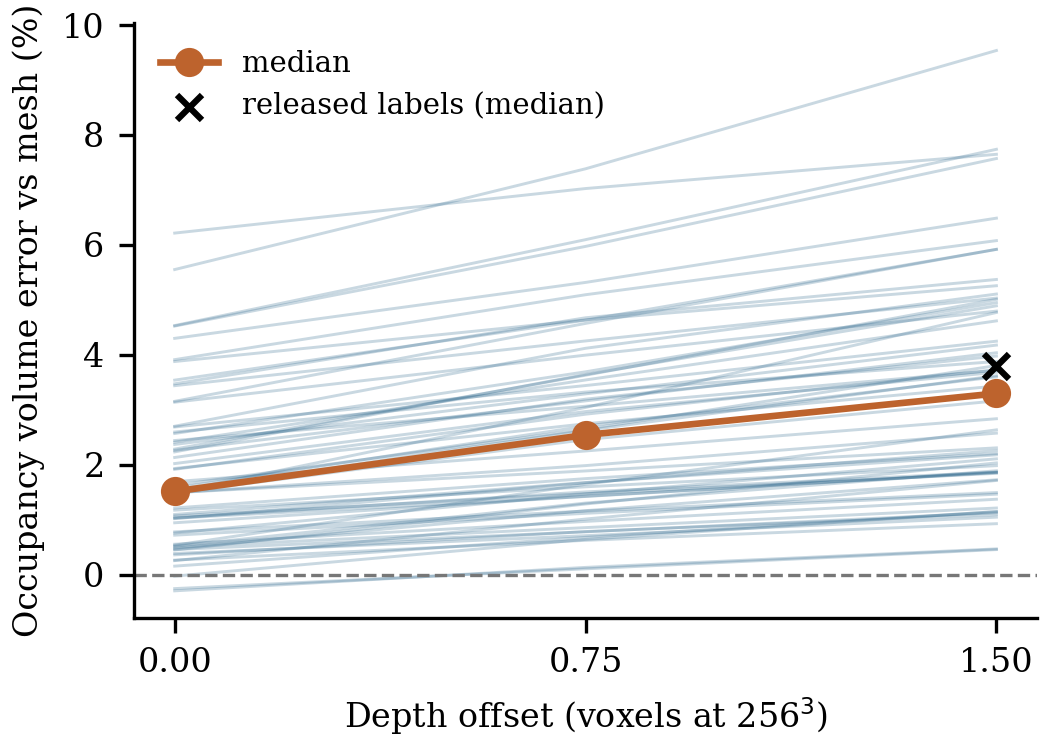

{
 "n_objects": 60,
 "convention_agreement_near_surface_at_1.5": {
  "centred": 0.9805153508573823,
  "literal": 0.902213289955522
 },
 "convention_used": "centred",
 "literal": {
  "by_offset": {
   "0.0": {
    "occ_err_median": 1.5777058665729093,
    "occ_err_mean": 1.8130180379827743,
    "fused_mesh_err_median": 1.662817415981488,
    "agree_all_median": 0.996585,
    "agree_near_median": 0.8852130709798858,
    "t50_median": 0.0013891649471587547,
    "n_watertight": 60
   },
   "0.75": {
    "occ_err_median": 2.4714288361716297,
    "occ_err_mean": 2.643361730745841,
    "fused_mesh_err_median": 2.3980859165899204,
    "agree_all_median": 0.9970650000000001,
    "agree_near_median": 0.897647639739285,
    "t50_median": 0.002070086088048854,
    "n_watertight": 60
   },
   "1.5": {
    "occ_err_median": 3.3898171670061705,
    "occ_err_mean": 3.4007983732038287,
    "fused_mesh_err_median": 3.056622561672706,
    "agree_all_median": 0.997275,
    "agree_near_median": 0.902213289

In [13]:
from IPython.display import Image, display
display(Image(os.path.join(OUT, 'recreation_full', 'offset_dose_response.png'), width=450))
print(open(os.path.join(OUT, 'recreation_full', 'recreation_summary.json')).read())

Send back this notebook with its outputs. I'll add the results to the paper (a controlled-test subsection and a supplementary sensitivity table).